# USD/KRW(달러-원) 환율 1년 트렌드 분석

- **기간**: 2025-09-19 ~ 2026-09-18 (영업일 기준, 최근 1년)
- **데이터 출처**: [Pound Sterling Live - USD/KRW History](https://www.poundsterlinglive.com/history/USD-KRW)
- **분석 질문**: `REPORT.md` 참고

이 노트북은 데이터 정제 → 시계열 분석 기법 적용 → 시각화 → (보너스) STL 분해 & 베이스라인 예측 순서로 구성되어 있습니다.

## 1. 라이브러리 불러오기 및 한글 폰트 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from statsmodels.tsa.seasonal import STL

# 한글 폰트 설정 (환경에 Noto Sans CJK가 있는 경우; 없으면 생략 가능)
try:
    font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
except Exception as e:
    print("한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다:", e)

plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_rows', 20)

## 2. 데이터 수집 방법 (요약)

원본 데이터는 Pound Sterling Live의 USD/KRW 히스토리 페이지(2025년, 2026년)를 조회하여 확보했습니다.
수집 및 파싱 과정은 `scripts/fetch_and_parse.py`에 기록되어 있으며, 결과물은 이미 `data/usdkrw_2025_2026.csv`로 저장되어 있습니다.
아래에서는 저장된 CSV를 불러오는 것으로 시작합니다 (재현 시 네트워크 접근 없이도 동일한 분석 결과를 재현할 수 있도록 하기 위함).

In [2]:
df = pd.read_csv("data/usdkrw_2025_2026.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
print("행 개수:", len(df))
print("기간:", df['date'].min().date(), "~", df['date'].max().date())
df.head()

행 개수: 261
기간: 2025-09-19 ~ 2026-09-18


,date,open,close,high,low,mid
0,2025-09-19,1388.25,1397.23,1399.70,1387.74,1393.720
1,2025-09-22,1397.23,1391.20,1398.17,1390.45,1394.310
2,2025-09-23,1391.20,1394.46,1395.77,1389.85,1392.810
3,2025-09-24,1394.46,1404.96,1405.60,1392.79,1399.195
4,2025-09-25,1404.95,1409.13,1411.55,1398.95,1405.250


## 3. 데이터 기본 정보 확인 (결측치 / 이상치)

In [3]:
print("=== 결측치 확인 ===")
print(df.isna().sum())

print("\n=== 영업일 기준 캘린더 대비 빠진 날짜 확인 ===")
full_range = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
weekdays = [d for d in full_range if d.weekday() < 5]
missing_weekdays = set(weekdays) - set(df['date'])
print("영업일 중 데이터 없는 날 수:", len(missing_weekdays))

print("\n=== 이상치 후보 확인 (mid 기준 |z-score| > 3) ===")
z = (df['mid'] - df['mid'].mean()) / df['mid'].std()
outliers = df[z.abs() > 3]
print("이상치 후보 개수:", len(outliers))

print("\n=== 기술통계 (mid) ===")
df['mid'].describe()

=== 결측치 확인 ===
date     0
open     0
close    0
high     0
low      0
mid      0
dtype: int64

=== 영업일 기준 캘린더 대비 빠진 날짜 확인 ===
영업일 중 데이터 없는 날 수: 0

=== 이상치 후보 확인 (mid 기준 |z-score| > 3) ===
이상치 후보 개수: 0

=== 기술통계 (mid) ===


count     261.000000
mean     1459.642069
std        45.159597
min      1338.210000
25%      1433.200000
50%      1467.470000
75%      1485.520000
max      1552.100000
Name: mid, dtype: float64

**결측치/이상치 처리 기준** (원본 데이터에는 실제로 결측치·이상치가 없었으나, 재현성을 위해 기준을 명시합니다):
- 결측치가 있다면: 휴장일로 간주하고 임의 보간하지 않고 제외
- 이상치 후보(|z|>3)가 있다면: 뉴스 등으로 실제 이벤트가 확인되면 유지, 명백한 데이터 입력 오류로 판단되면 제거

## 4. 시계열 분석 기법 적용

In [4]:
# 기법 1: 이동평균 (7일, 30일)
df['ma7'] = df['mid'].rolling(7).mean()
df['ma30'] = df['mid'].rolling(30).mean()

# 기법 2: 일별 변화율(%)
df['pct_change'] = df['mid'].pct_change() * 100

# 기법 3: 월별 통계 (평균, 표준편차=변동성)
df['year_month'] = df['date'].dt.to_period('M')
monthly = df.groupby('year_month')['mid'].agg(['mean','std','min','max']).round(2)

# 기법 4: 요일별 평균 변화율
df['weekday'] = df['date'].dt.day_name()
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday']
weekday_stats = df.groupby('weekday')['pct_change'].mean().reindex(weekday_order).round(4)

monthly

,mean,std,min,max
year_month,,,,
2025-09,1400.34,6.51,1392.81,1411.14
2025-10,1423.16,9.53,1403.90,1436.74
2025-11,1459.92,12.31,1429.29,1474.65
2025-12,1465.18,13.68,1435.84,1481.24
2026-01,1455.04,14.99,1428.26,1476.82
2026-02,1448.16,10.27,1428.42,1468.51
2026-03,1490.26,16.02,1456.70,1520.90
2026-04,1485.04,13.51,1470.02,1515.53
2026-05,1489.19,18.93,1451.90,1513.40


In [5]:
weekday_stats

weekday
Monday      -0.0370
Tuesday      0.0464
Wednesday   -0.0816
Thursday     0.0011
Friday       0.0640
Name: pct_change, dtype: float64

In [6]:
print("=== 일간 변화율 TOP5 (급등) ===")
display(df.nlargest(5, 'pct_change')[['date','mid','pct_change']])

print("\n=== 일간 변화율 BOTTOM5 (급락) ===")
display(df.nsmallest(5, 'pct_change')[['date','mid','pct_change']])

=== 일간 변화율 TOP5 (급등) ===


,date,mid,pct_change
117,2026-03-03,1480.660,1.644465
116,2026-03-02,1456.705,1.284213
258,2026-09-16,1370.695,1.120989
96,2026-02-02,1456.910,1.117778
167,2026-05-12,1484.200,1.007214



=== 일간 변화율 BOTTOM5 (급락) ===


,date,mid,pct_change
187,2026-06-09,1522.60,-1.309628
68,2025-12-24,1462.19,-1.285751
69,2025-12-25,1444.51,-1.209145
143,2026-04-08,1485.45,-1.208746
208,2026-07-08,1510.36,-1.084212


## 5. 시각화

### 5-1. 가격 추세 및 이동평균

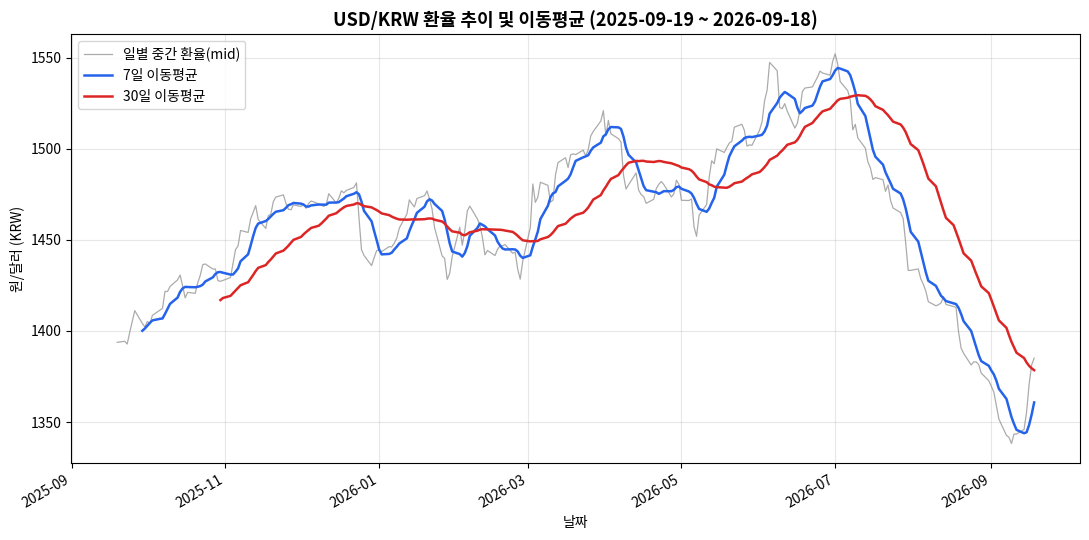

In [7]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(df['date'], df['mid'], label='일별 중간 환율(mid)', color='#888888', linewidth=0.9, alpha=0.7)
ax.plot(df['date'], df['ma7'], label='7일 이동평균', color='#2563eb', linewidth=1.8)
ax.plot(df['date'], df['ma30'], label='30일 이동평균', color='#dc2626', linewidth=1.8)
ax.set_title('USD/KRW 환율 추이 및 이동평균 (2025-09-19 ~ 2026-09-18)', fontsize=13, fontweight='bold')
ax.set_xlabel('날짜'); ax.set_ylabel('원/달러 (KRW)')
ax.legend(loc='upper left'); ax.grid(alpha=0.3)
fig.autofmt_xdate(); plt.tight_layout()
plt.savefig('images/01_price_trend_ma.png', dpi=150)
plt.show()

### 5-2. 월별 평균 및 변동성(표준편차)

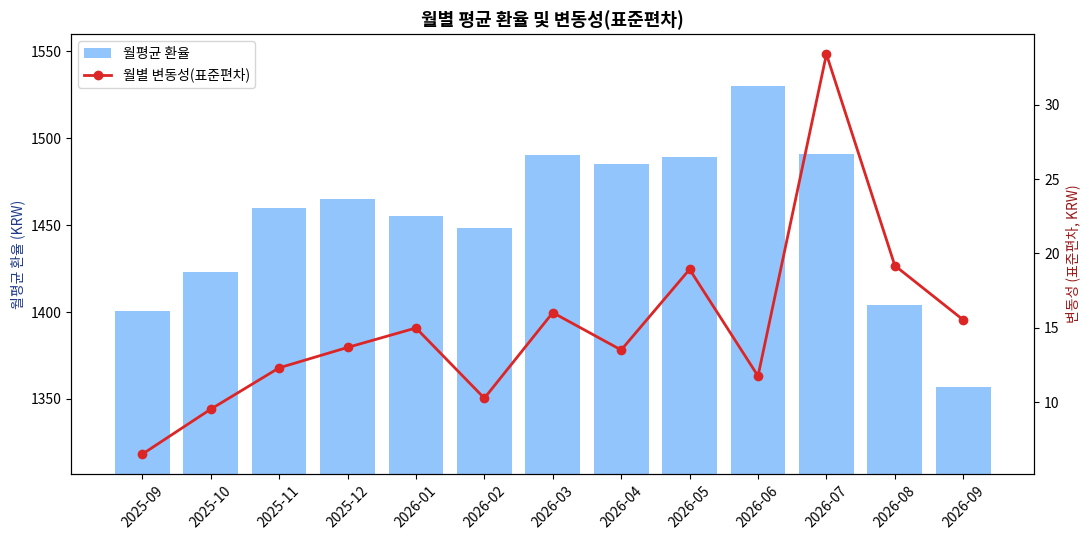

In [8]:
fig, ax1 = plt.subplots(figsize=(11, 5.5))
x = range(len(monthly))
ax1.bar(x, monthly['mean'], color='#93c5fd', label='월평균 환율')
ax1.set_ylabel('월평균 환율 (KRW)', color='#1e3a8a')
ax1.set_xticks(x); ax1.set_xticklabels([str(p) for p in monthly.index], rotation=45)
ax1.set_ylim(monthly['mean'].min()-50, monthly['mean'].max()+30)

ax2 = ax1.twinx()
ax2.plot(x, monthly['std'], color='#dc2626', marker='o', linewidth=2, label='월별 변동성(표준편차)')
ax2.set_ylabel('변동성 (표준편차, KRW)', color='#991b1b')

ax1.set_title('월별 평균 환율 및 변동성(표준편차)', fontsize=13, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
plt.savefig('images/02_monthly_mean_volatility.png', dpi=150)
plt.show()

### 5-3. 일별 변화율 분포 및 요일별 패턴

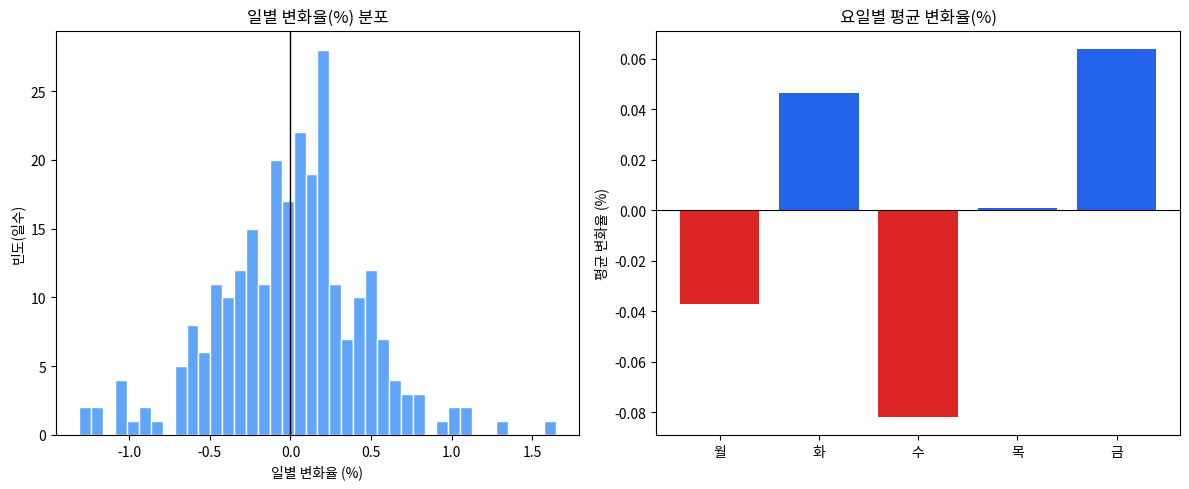

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df['pct_change'].dropna(), bins=40, color='#60a5fa', edgecolor='white')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('일별 변화율(%) 분포'); axes[0].set_xlabel('일별 변화율 (%)'); axes[0].set_ylabel('빈도(일수)')

weekday_kr = {'Monday':'월','Tuesday':'화','Wednesday':'수','Thursday':'목','Friday':'금'}
colors = ['#dc2626' if v < 0 else '#2563eb' for v in weekday_stats.values]
axes[1].bar([weekday_kr[d] for d in weekday_order], weekday_stats.values, color=colors)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('요일별 평균 변화율(%)'); axes[1].set_ylabel('평균 변화율 (%)')

plt.tight_layout()
plt.savefig('images/03_change_distribution_weekday.png', dpi=150)
plt.show()

## 6. (보너스 심화 A) STL 시계열 분해

추세(Trend) / 계절성(Seasonal, 영업일 주기=5) / 잔차(Residual)로 분해합니다.

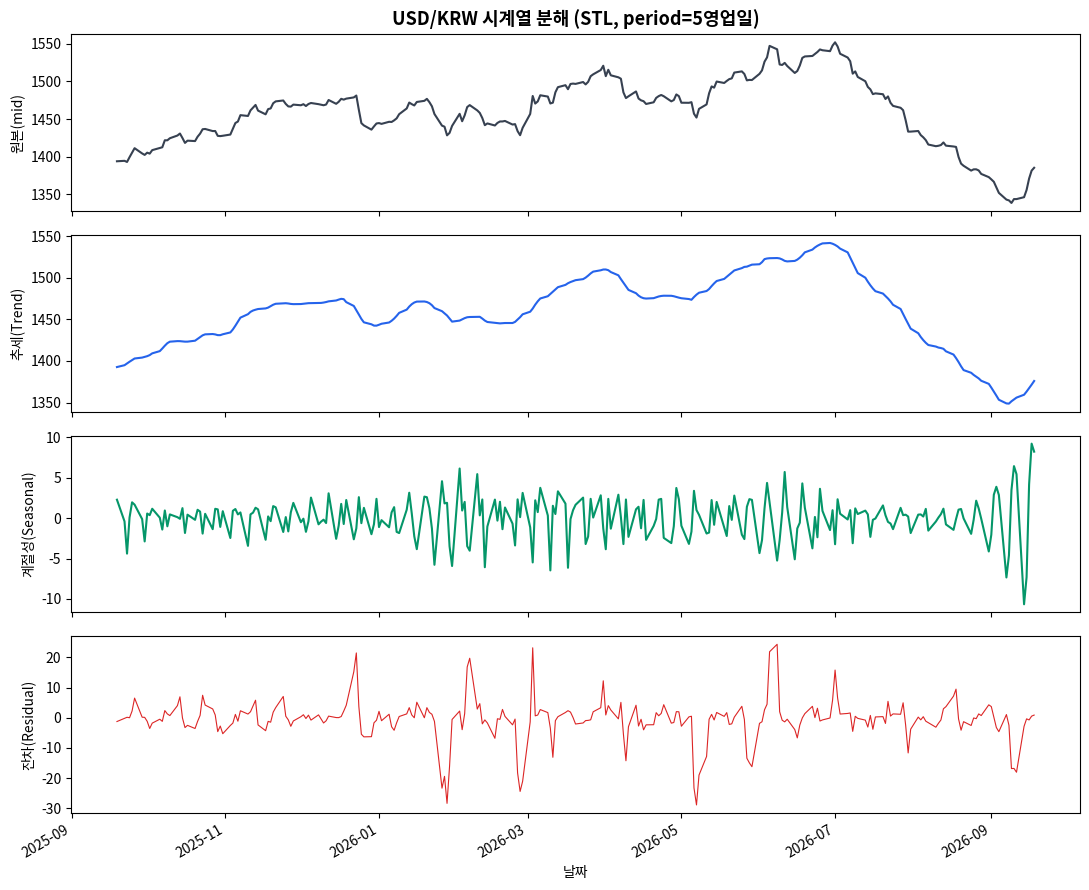

추세 표준편차: 44.0
계절성 표준편차: 2.58
잔차 표준편차: 6.88


In [10]:
series = df.set_index('date')['mid']
stl = STL(series, period=5, robust=True)
res = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(series.index, series.values, color='#374151'); axes[0].set_ylabel('원본(mid)')
axes[0].set_title('USD/KRW 시계열 분해 (STL, period=5영업일)', fontsize=13, fontweight='bold')
axes[1].plot(res.trend.index, res.trend.values, color='#2563eb'); axes[1].set_ylabel('추세(Trend)')
axes[2].plot(res.seasonal.index, res.seasonal.values, color='#059669'); axes[2].set_ylabel('계절성(Seasonal)')
axes[3].plot(res.resid.index, res.resid.values, color='#dc2626', linewidth=0.8); axes[3].set_ylabel('잔차(Residual)')
axes[3].set_xlabel('날짜')
fig.autofmt_xdate(); plt.tight_layout()
plt.savefig('images/04_stl_decomposition.png', dpi=150)
plt.show()

print("추세 표준편차:", round(res.trend.std(), 2))
print("계절성 표준편차:", round(res.seasonal.std(), 2))
print("잔차 표준편차:", round(res.resid.std(), 2))

**해석**: 변동의 대부분이 추세 성분에서 발생하며, 요일 단위 계절성은 상대적으로 미미합니다.
**한계**: `period=5`는 영업일 기준 주간 주기를 가정한 것으로, 이 가정이 실제 시장 구조를 반영하는지는 추가 검증이 필요합니다.

## 7. (보너스 심화 B) 베이스라인 예측

최근 10영업일을 홀드아웃으로 두고 Naive(직전값 유지) vs MA5(최근 5일 평균) 방식의 정확도(MAE)를 비교한 뒤,
전체 데이터로 향후 5영업일을 예측합니다.

[검증] 최근 10영업일 홀드아웃 MAE - Naive: 14.06 KRW
[검증] 최근 10영업일 홀드아웃 MAE - MA5: 18.18 KRW


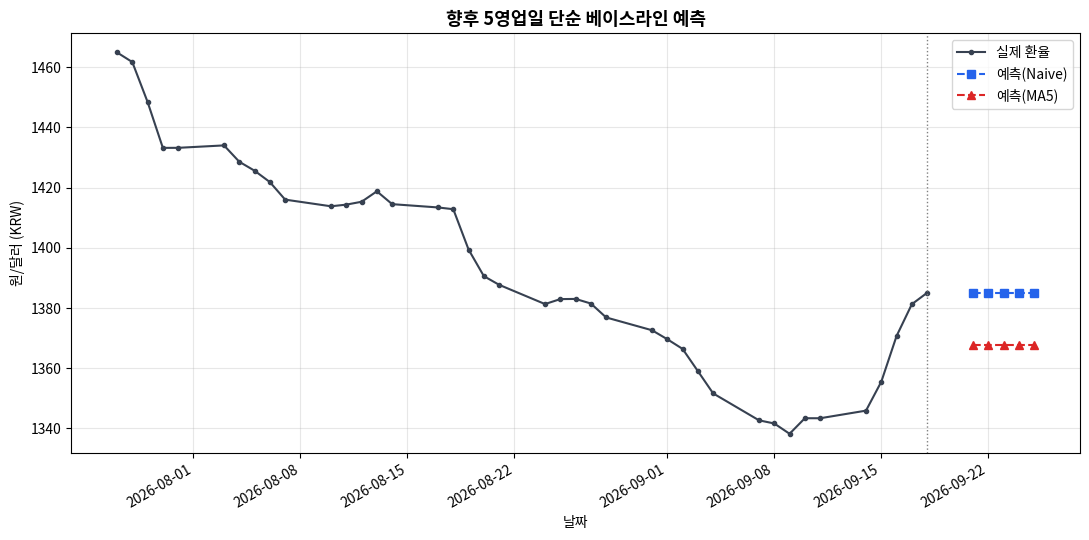

In [11]:
holdout = 10
train = df.iloc[:-holdout]
test = df.iloc[-holdout:]

naive_pred = np.repeat(train['mid'].iloc[-1], holdout)
ma_pred = np.repeat(train['mid'].iloc[-5:].mean(), holdout)

mae_naive = np.mean(np.abs(test['mid'].values - naive_pred))
mae_ma = np.mean(np.abs(test['mid'].values - ma_pred))
print(f"[검증] 최근 {holdout}영업일 홀드아웃 MAE - Naive: {mae_naive:.2f} KRW")
print(f"[검증] 최근 {holdout}영업일 홀드아웃 MAE - MA5: {mae_ma:.2f} KRW")

last_val = df['mid'].iloc[-1]
last_ma5 = df['mid'].iloc[-5:].mean()
future_dates = pd.bdate_range(df['date'].iloc[-1] + pd.Timedelta(days=1), periods=5)

fig, ax = plt.subplots(figsize=(11, 5.5))
recent = df.iloc[-40:]
ax.plot(recent['date'], recent['mid'], label='실제 환율', color='#374151', marker='o', markersize=3)
ax.plot(future_dates, [last_val]*5, label='예측(Naive)', color='#2563eb', linestyle='--', marker='s')
ax.plot(future_dates, [last_ma5]*5, label='예측(MA5)', color='#dc2626', linestyle='--', marker='^')
ax.axvline(df['date'].iloc[-1], color='gray', linestyle=':', linewidth=1)
ax.set_title('향후 5영업일 단순 베이스라인 예측', fontsize=13, fontweight='bold')
ax.set_xlabel('날짜'); ax.set_ylabel('원/달러 (KRW)')
ax.legend(); ax.grid(alpha=0.3)
fig.autofmt_xdate(); plt.tight_layout()
plt.savefig('images/05_baseline_forecast.png', dpi=150)
plt.show()

**주의**: 이 예측은 베이스라인 개념 설명용이며, 실제 환율은 금리·지정학적 이벤트 등 예측불가 변수에 크게 좌우되므로 투자/환전 판단에 사용해서는 안 됩니다.

## 8. 결론

자세한 인사이트와 결론, 한계점, AI 사용 로그는 `REPORT.md`를 참고하세요.

In [12]:
df.to_csv("data/usdkrw_processed.csv", index=False)
print("전처리된 데이터 저장 완료: data/usdkrw_processed.csv")

전처리된 데이터 저장 완료: data/usdkrw_processed.csv
